In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Japan Segmentation, Morphological Operations, Object Properties in Images

## Images Used
   - Go Board https://www.fun-japan.jp/my/articles/9564

In [2]:
def show_pair(a, b, titles=("Original", "Processed"), figsize=(10, 5), cmap='gray'):
    plt.figure(figsize=figsize)

    # left
    plt.subplot(1, 2, 1)
    if a.ndim == 2:
        plt.imshow(a, cmap=cmap)
    else:
        plt.imshow(a)
    plt.title(titles[0])
    plt.axis('off')

    # right
    plt.subplot(1, 2, 2)
    if b.ndim == 2:
        plt.imshow(b, cmap=cmap)
    else:
        plt.imshow(b)
    plt.title(titles[1])
    plt.axis('off')

    plt.show()

In [3]:
def load_rgb(path: str, dummy: bool = False, size: tuple[int, int] = (720, 1080)) -> np.ndarray:
    if os.path.exists(path) and not dummy:
        img_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
        if img_bgr is None:
            dummy = True
        else:
            return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    # dummy: colorful gradient + noise
    h, w = size
    y = np.linspace(0, 1, h)[:, None]
    x = np.linspace(0, 1, w)[None, :]
    r = x
    g = y
    b = 1 - 0.5 * (x + y)
    img = np.stack([r, g, b], axis=2)
    img += 0.05 * np.random.RandomState(42).randn(h, w, 3)
    img = np.clip(img, 0, 1)
    return (img * 255).astype(np.uint8)


In [4]:
def save_rgb(path: str, img_rgb: np.ndarray):
    bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(path, bgr)

## Day 9

### Use Case (Japan) – Go Board Segmentation

Automatically **segment and count Go stones** from overhead board photos to reconstruct the game state (stone counts and positions).

#### Problem
Go boards (19×19 grid) can be densely packed with black/white stones that:
- Touch or nearly touch each other
- Show reflections and lighting variation

We need to **detect each stone and its exact grid intersection** from a single image.

#### Why
- Go is a major traditional game and a clean benchmark for grid-based vision tasks.
- Automatic board recognition enables:
  - Digital game recording from real boards
  - Training data for Go AI from amateur/pro play
  - A controlled proxy task for methods later applied to complex scenes (e.g., shelves, vending machines).

#### Target Outputs per Image
- **Total stones** on the board
- **Black vs. white stone counts**
- **Coordinates of each stone** (board intersections)
- Optional:
  - Approximate **territory regions**
  - List of **empty intersections**
  - Basic group/shape features (large groups, eyes)

#### Selected Image
- Overhead view of a **single Go board** on a table
- Standard grid with many intersections
- Numerous **black and white stones** placed on the board, often touching, ideal for segmentation and counting.


In [5]:
GO_PATH = "Data/Go.png"
img_go = load_rgb(GO_PATH)

save_rgb('images/jo.jpg', img_go)

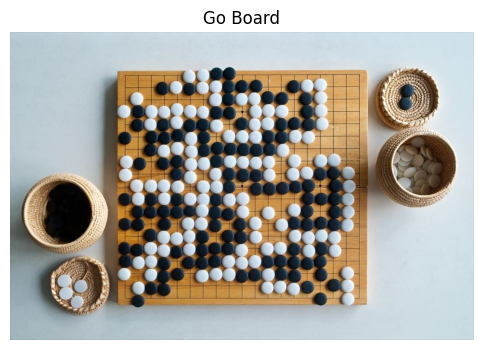

In [6]:
plt.figure(figsize=(6,4)); plt.imshow(img_go); plt.title("Go Board"); plt.axis("off"); plt.show()

## Day 10

### Crop to Board

In [7]:
def crop_board_custom(
    img: np.ndarray,
    top_ratio: float = 0.1,
    bottom_ratio: float = 0.1,
    left_ratio: float = 0.1,
    right_ratio: float = 0.1,
) -> np.ndarray:

    h, w = img.shape[:2]

    # convert ratios to pixel offsets
    top    = int(h * top_ratio)
    bottom = int(h * bottom_ratio)
    left   = int(w * left_ratio)
    right  = int(w * right_ratio)

    y0 = top
    y1 = h - bottom
    x0 = left
    x1 = w - right

    # safety clamp
    y0 = max(0, min(y0, h-1))
    y1 = max(y0+1, min(y1, h))
    x0 = max(0, min(x0, w-1))
    x1 = max(x0+1, min(x1, w))

    return img[y0:y1, x0:x1]

In [8]:
img_board = crop_board_custom(
    img_go,
    top_ratio=0.1,
    bottom_ratio=0.1,
    left_ratio=0.225,
    right_ratio=0.225,
)

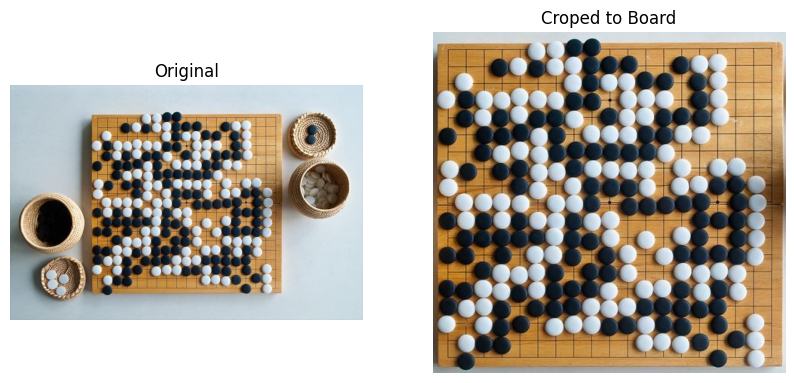

In [9]:
show_pair(img_go, img_board, titles=("Original", "Croped to Board"))

### K-Means Segmentation

In [10]:
def kmeans_segment_board(
        img_board: np.ndarray,
        K: int = 3,
        use_lab_weighted: bool = True,
        blur_ksize: int = 0,
        max_iter: int = 20,
        attempts: int = 5,
) -> tuple[np.ndarray, np.ndarray]:
    img = img_board.copy()

    if blur_ksize and blur_ksize > 1:
        if blur_ksize % 2 == 0:
            blur_ksize += 1
        img = cv2.GaussianBlur(img, (blur_ksize, blur_ksize), 0)

    # feature space: Lab with re-weighted channels
    if use_lab_weighted:
        img_lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB).astype(np.float32)
        L, a, b = cv2.split(img_lab)

        # CLAHE on L channel
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        L = clahe.apply(L.astype(np.uint8)).astype(np.float32)

        L_w = L * 0.4  # brightness: lower weight
        a_w = a * 1.2  # chroma: higher weight
        b_w = b * 1.2

        feat = np.stack([L_w, a_w, b_w], axis=-1)  # (H, W, 3)
        Z = feat.reshape((-1, 3)).astype(np.float32)
    else:
        Z = img.reshape((-1, 3)).astype(np.float32)

    criteria = (
        cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
        max_iter,
        1.0,
    )

    # noinspection PyTypeChecker
    _, labels_flat, _ = cv2.kmeans(
        Z, K, None, criteria, attempts, cv2.KMEANS_RANDOM_CENTERS
    )

    labels_km = labels_flat.reshape(img_board.shape[:2])

    # compute mean RGB color of each cluster
    centers_rgb = np.zeros((K, 3), dtype=np.float32)
    for k in range(K):
        mask = (labels_km == k)
        if np.any(mask):
            centers_rgb[k] = img_board[mask].mean(axis=0)
    centers_rgb = centers_rgb.astype(np.uint8)

    return labels_km, centers_rgb

In [11]:
def experiment_kmeans_board(
        img_board: np.ndarray,
        Ks: list[int] | tuple[int, ...] = (2, 3, 4),
        blur_values: list[int] | tuple[int, ...] = (0, 3, 5),
        use_lab_options: list[bool] | tuple[bool, ...] = (False, True),
):
    km_results = {}
    for K in Ks:
        for blur_ksize in blur_values:
            for use_lab in use_lab_options:
                labels_km, centers_rgb = kmeans_segment_board(
                    img_board,
                    K=K,
                    use_lab_weighted=use_lab,
                    blur_ksize=blur_ksize,
                    max_iter=20,
                    attempts=5,
                )
                key = f"kmeans_K{K}_blur{blur_ksize}_lab{int(use_lab)}"
                km_results[key] = {
                    "labels": labels_km,
                    "centers_rgb": centers_rgb,
                }

    return km_results

In [12]:
def semantic_colorize(labels: np.ndarray, centers_rgb: np.ndarray):
    K = centers_rgb.shape[0]
    brightness = centers_rgb.mean(axis=1)
    order = np.argsort(brightness)

    label_black = order[0]
    label_white = order[-1]
    label_board = order[1] if K >= 3 else None

    remap = np.full(K, 3, dtype=np.int32)  # default 'other'
    remap[label_black] = 0
    remap[label_white] = 1
    if label_board is not None:
        remap[label_board] = 2

    # Adjusted semantic labels (same shape as `labels`)
    labels_sem = remap[labels]

    label_to_color = np.array([
        [0, 0, 0],       # 0 -> black stones
        [255, 255, 255], # 1 -> white stones
        [0, 255, 0],     # 2 -> board
        [255, 0, 0],     # 3 -> other
    ], dtype=np.uint8)

    vis = label_to_color[labels_sem]

    # Return both the visualization and the adjusted labels
    return vis, labels_sem

In [13]:
def show_kmeans_experiments_grid_structured(
        km_results: dict,
        Ks,
        blur_values,
        use_lab_options,
        figsize=(12, 8),
):
    for use_lab in use_lab_options:
        lab_flag = int(use_lab)
        n_rows = len(Ks)
        n_cols = len(blur_values)

        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
        axes = np.array(axes)
        if axes.ndim == 1:
            axes = axes.reshape(n_rows, n_cols)

        for i, K in enumerate(Ks):
            for j, blur_ksize in enumerate(blur_values):
                key = f"kmeans_K{K}_blur{blur_ksize}_lab{lab_flag}"
                ax = axes[i, j]

                if key not in km_results:
                    ax.axis("off")
                    ax.set_title(f"Missing: {key}", fontsize=8)
                    continue

                data = km_results[key]
                labels = data["labels"]
                centers = data["centers_rgb"]

                # <<< static semantic colors here
                vis, _ = semantic_colorize(labels, centers)

                ax.imshow(vis)
                ax.set_title(f"K={K}, blur={blur_ksize}", fontsize=8)
                ax.axis("off")

        fig.suptitle(f"K-means results (use_lab_weighted={use_lab})", fontsize=12)
        plt.tight_layout()
        plt.show()

### Find best Parameters

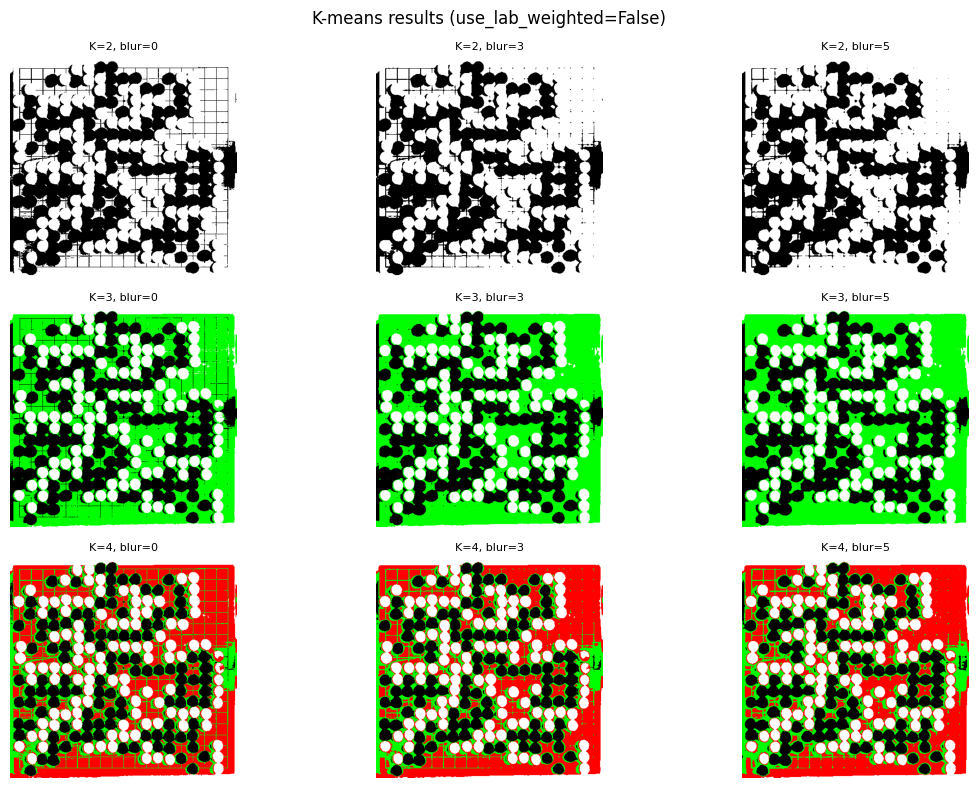

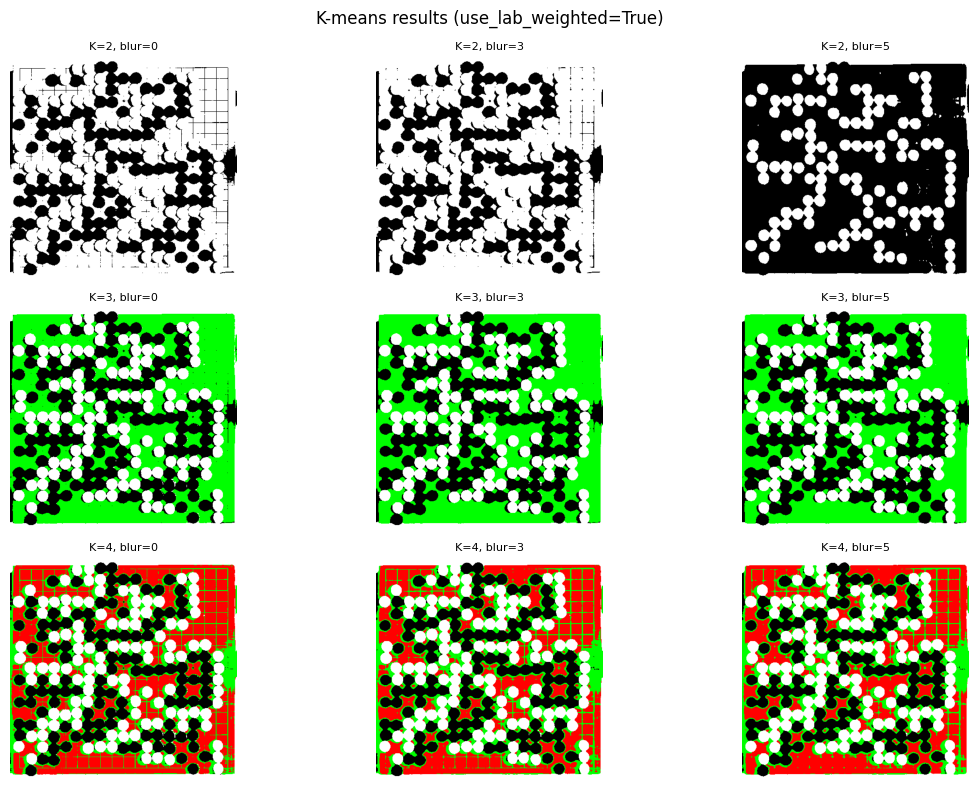

In [14]:
Ks = [2, 3, 4]
blur_values = [0, 3, 5]
use_lab_options = [False, True]

km_results = experiment_kmeans_board(
    img_board,
    Ks=Ks,
    blur_values=blur_values,
    use_lab_options=use_lab_options,
)

show_kmeans_experiments_grid_structured(
    km_results,
    Ks=Ks,
    blur_values=blur_values,
    use_lab_options=use_lab_options,
    figsize=(12, 8),
)

### Best Parameters

In [15]:
key = "kmeans_K4_blur3_lab1"

In [16]:
best = km_results[key]
labels_best = best["labels"]
centers_best = best["centers_rgb"]

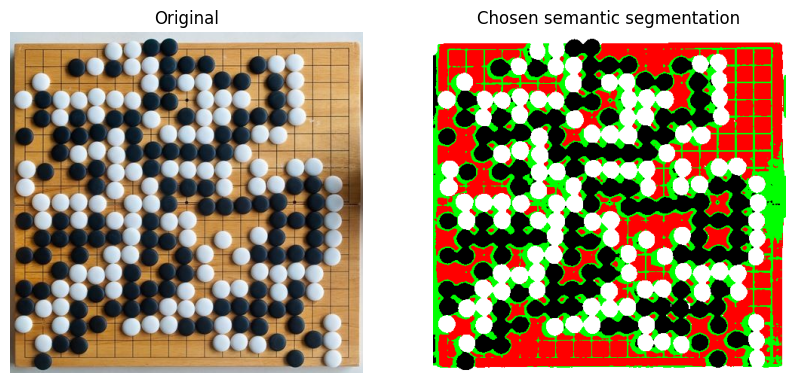

In [17]:
vis_semantic, labels_sem = semantic_colorize(labels_best, centers_best)

show_pair(img_board, vis_semantic,titles=("Original", "Chosen semantic segmentation"))

## Day 11

In [18]:
def make_binary_mask(labels_sem: np.ndarray, target_class: int) -> np.ndarray:
    mask = (labels_sem == target_class).astype(np.uint8) * 255
    return mask

mask_black = make_binary_mask(labels_sem, 0)
mask_white = make_binary_mask(labels_sem, 1)
mask_board = make_binary_mask(labels_sem, 2)
mask_other = make_binary_mask(labels_sem, 3)

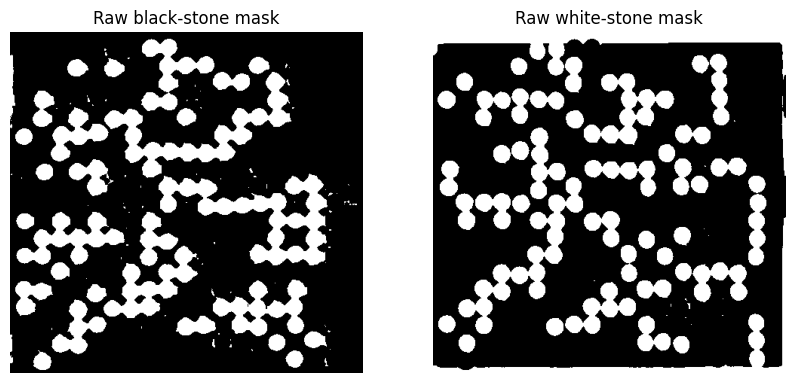

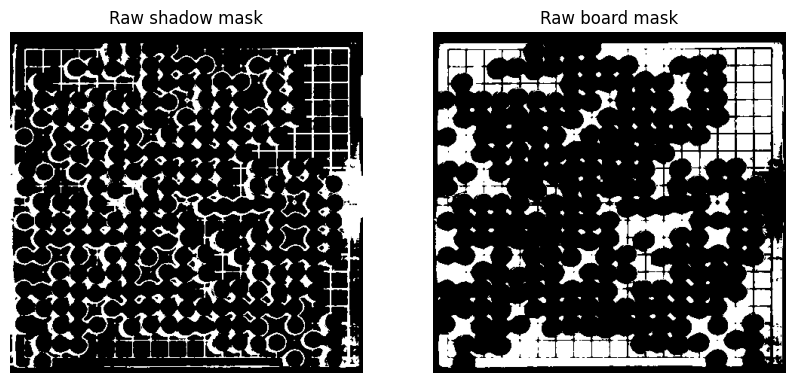

In [19]:
show_pair(mask_black, mask_white, titles=("Raw black-stone mask", "Raw white-stone mask"))
show_pair(mask_board, mask_other, titles=("Raw shadow mask", "Raw board mask"))

### Morphological denoising / rounding

In [50]:
kernel3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
kernel5 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

def morph_smooth(mask):
    steps = {}
    steps["raw"] = mask

    # Opening
    steps["open_3"] = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel3)
    steps["open_5"] = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel5)

    # Closing after open_3
    steps["open3_close3"] = cv2.morphologyEx(steps["open_3"], cv2.MORPH_CLOSE, kernel3)
    steps["open3_close5"] = cv2.morphologyEx(steps["open_3"], cv2.MORPH_CLOSE, kernel5)

    # Closing after open_5 (this branch is what you’ll actually use)
    steps["open5_close3"] = cv2.morphologyEx(steps["open_5"], cv2.MORPH_CLOSE, kernel3)
    steps["open5_close5"] = cv2.morphologyEx(steps["open_5"], cv2.MORPH_CLOSE, kernel5)

    return steps

In [53]:
def plot_morph_overview(steps, name="Mask"):

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    # Row 1: Open3 branch
    axes[0, 0].imshow(steps["open_3"], cmap="gray")
    axes[0, 0].set_title(f"{name}: Open (3x3)")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(steps["open3_close3"], cmap="gray")
    axes[0, 1].set_title(f"{name}: Open3 + Close3")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(steps["open3_close5"], cmap="gray")
    axes[0, 2].set_title(f"{name}: Open3 + Close5")
    axes[0, 2].axis("off")

    # Row 2: Open5 branch
    axes[1, 0].imshow(steps["open_5"], cmap="gray")
    axes[1, 0].set_title(f"{name}: Open (5x5)")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(steps["open5_close3"], cmap="gray")
    axes[1, 1].set_title(f"{name}: Open5 + Close3")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(steps["open5_close5"], cmap="gray")
    axes[1, 2].set_title(f"{name}: Open5 + Close5")
    axes[1, 2].axis("off")

    plt.tight_layout()
    plt.show()

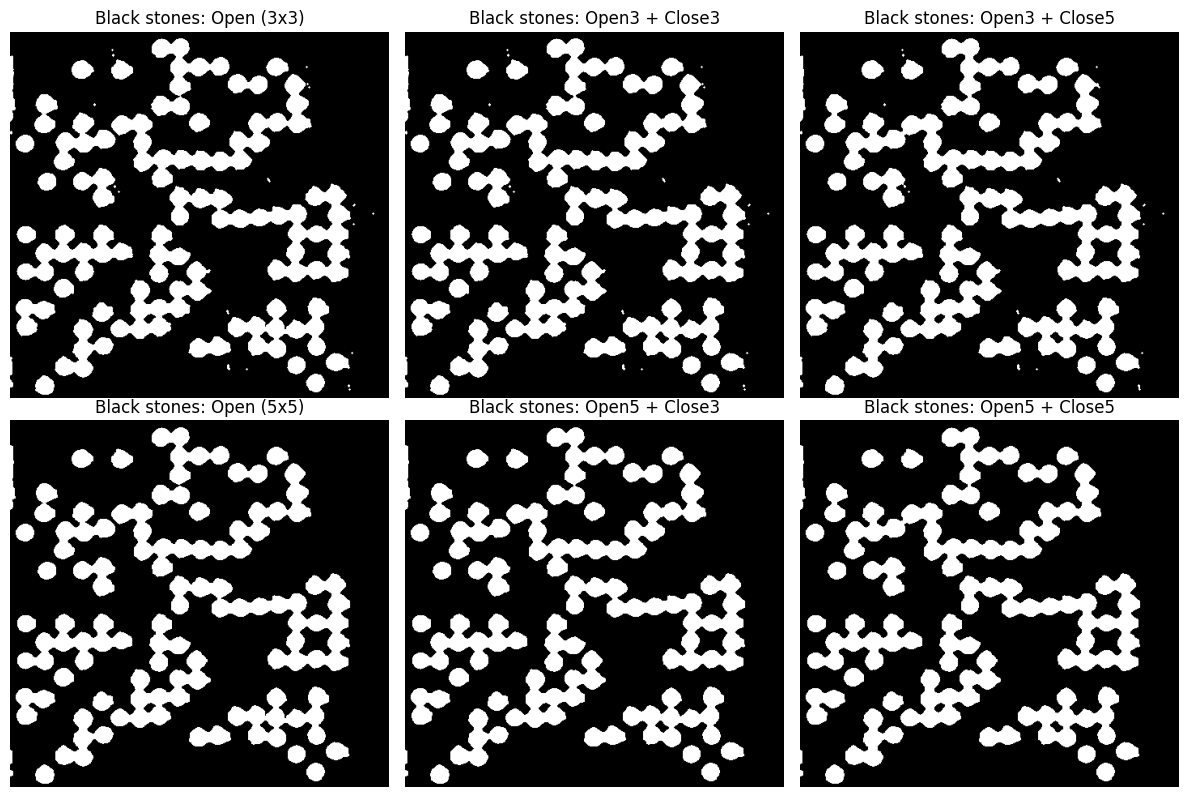

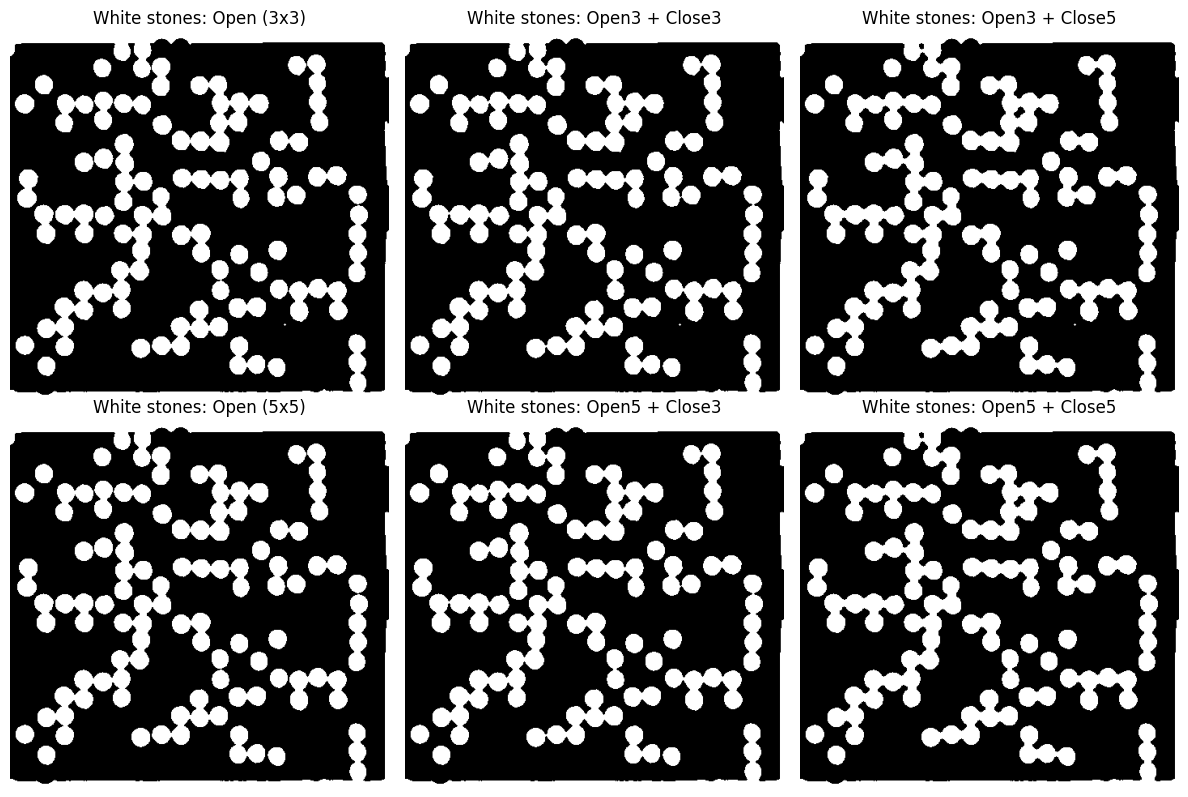

In [54]:
steps_black = morph_smooth(mask_black)
steps_white = morph_smooth(mask_white)

plot_morph_overview(steps_black, "Black stones")
plot_morph_overview(steps_white, "White stones")

### Best Method

We chose Open5 since any further processing had no viseable benefit.

In [55]:
mask_black_clean = steps_black["open_5"]
mask_white_clean = steps_white["open_5"]

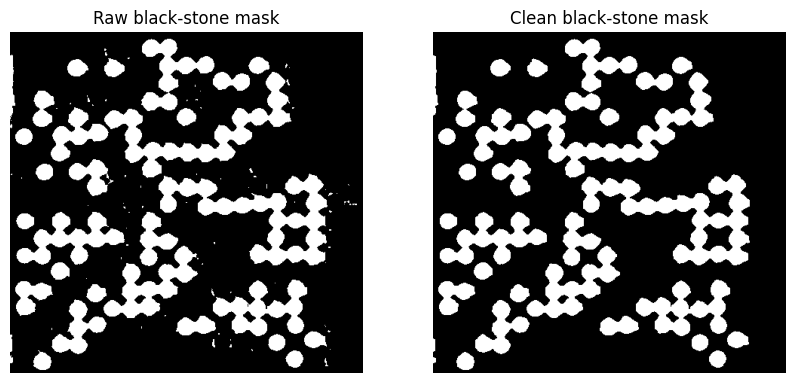

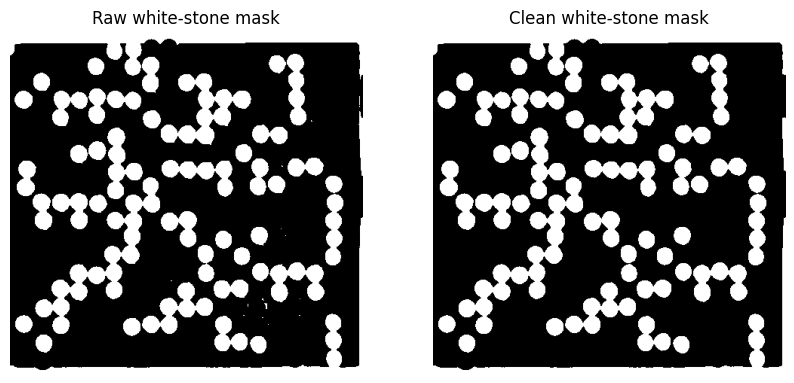

In [56]:
show_pair(mask_black, mask_black_clean, titles=("Raw black-stone mask", "Clean black-stone mask"))
show_pair(mask_white, mask_white_clean, titles=("Raw white-stone mask", "Clean white-stone mask"))